Movie Industry Exploratory Data Analysis

1. import & setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12,8)

2.load data

In [35]:
# Load all datasets
movie_dates_df = pd.read_csv('/content/movie_release_dates.csv')
theaters_df = pd.read_csv('/content/movie_theater_data.csv')
awards_df = pd.read_csv('/content/movie_awards.csv')
actors_df = pd.read_csv('/content/Actors_Table.csv')
directors_df = pd.read_csv('/content/Directors_Table.csv')
imdb_base_df = pd.read_csv('/content/IMDb_base.csv')
imdb_budgets_df = pd.read_csv('/content/IMDb_budgets.csv')
studio_df = pd.read_csv('/content/studiodf.csv')

3.basic cleaning

In [39]:
# Remove duplicates
imdb_budgets_df = imdb_budgets_df.drop_duplicates()

# Remove rows with missing values
imdb_budgets_df = imdb_budgets_df.dropna(subset=['Production Budget', 'Worldwide Gross'])

# Convert to numeric
imdb_budgets_df['Production Budget'] = pd.to_numeric(imdb_budgets_df['Production Budget'], errors='coerce')
imdb_budgets_df['Worldwide Gross'] = pd.to_numeric(imdb_budgets_df['Worldwide Gross'], errors='coerce')

4. Create Profit & ROI 💰

In [40]:
# Profit
imdb_budgets_df['Profit'] = imdb_budgets_df['Worldwide Gross'] - imdb_budgets_df['Production Budget']

# ROI
imdb_budgets_df['ROI'] = imdb_budgets_df['Profit'] / imdb_budgets_df['Production Budget']

# Check
imdb_budgets_df[['Movie', 'Production Budget', 'Worldwide Gross', 'Profit', 'ROI']].head()

,Movie,Production Budget,Worldwide Gross,Profit,ROI
0,Avengers: Endgame,400000000,2797800564,2397800564,5.99
1,Avatar,237000000,2788701337,2551701337,10.77
2,Black Panther,200000000,1346103376,1146103376,5.73
3,Avengers: Infinity War,300000000,2048359754,1748359754,5.83
4,Titanic,200000000,2208208395,2008208395,10.04


5.fix genre column

In [47]:
# Convert to string
imdb_budgets_df['Genre'] = imdb_budgets_df['Genre'].astype(str)

# Split multiple genres
imdb_budgets_df['Genre'] = imdb_budgets_df['Genre'].str.split(', ')

# Explode (IMPORTANT)
genre_df = imdb_budgets_df.explode('Genre')

# Remove null values
genre_df = genre_df.dropna(subset=['Genre'])

# Reset index (clean)
genre_df = genre_df.reset_index(drop=True)

# Check
genre_df[['Movie', 'Genre']].head()

,Movie,Genre
0,Avengers: Endgame,['Action'
1,Avengers: Endgame,'Adventure'
2,Avengers: Endgame,'Drama']
3,Avatar,['Action'
4,Avatar,'Adventure'


# Question 1: What are the most profitable movies and how much should you spend?

In [48]:
top_profit_movies = imdb_budgets_df.sort_values(by='Profit', ascending=False).head(10)

top_profit_movies[['Movie', 'Production Budget', 'Worldwide Gross', 'Profit']]

,Movie,Production Budget,Worldwide Gross,Profit
1,Avatar,237000000,2788701337,2551701337
0,Avengers: Endgame,400000000,2797800564,2397800564
4,Titanic,200000000,2208208395,2008208395
3,Avengers: Infinity War,300000000,2048359754,1748359754
5,Jurassic World,215000000,1670400637,1455400637
8,The Lion King,260000000,1656943394,1396943394
40,Furious 7,190000000,1518722794,1328722794
13,Frozen II,150000000,1447549711,1297549711
6,The Avengers,225000000,1515100211,1290100211
2,Black Panther,200000000,1346103376,1146103376


# Question 2: Which movie genres are most commonly produced and does quantity equate to higher net profits?

In [49]:
# Count of movies per genre
genre_count = genre_df['Genre'].value_counts()

# Average profit per genre
genre_profit = genre_df.groupby('Genre')['Profit'].mean().sort_values(ascending=False)

print("Top Genres by Count:")
print(genre_count.head(10))

print("\nTop Genres by Profit:")
print(genre_profit.head(10))

Top Genres by Count:
Genre
['Action'      1038
['Comedy'       850
'Drama'         758
'Thriller']     629
'Romance']      574
'Adventure'     572
'Drama']        546
['Drama'        506
'Crime'         315
'Sci-Fi']       278
Name: count, dtype: int64

Top Genres by Profit:
Genre
['Family'      549383342.00
['Musical'     381508097.00
['Animation'   244811078.25
'Adventure']   240659916.05
'Adventure'    218033504.57
'Comedy']      198660507.71
'Action'       181327822.21
'Sci-Fi']      175088564.10
'Fantasy']     151819077.29
'Family'       128643003.89
Name: Profit, dtype: float64


# Question 3: What is the best time of the year to release a movie?

In [51]:
# Convert safely
imdb_budgets_df['Release Date'] = pd.to_datetime(
    imdb_budgets_df['Release Date'],
    errors='coerce'
)

# Remove invalid dates
imdb_budgets_df = imdb_budgets_df.dropna(subset=['Release Date'])

# Extract month
imdb_budgets_df['Month'] = imdb_budgets_df['Release Date'].dt.month

# Profit by month
monthly_profit = imdb_budgets_df.groupby('Month')['Profit'].mean()

# Sort
monthly_profit = monthly_profit.sort_values(ascending=False)

monthly_profit

,Profit
Month,
5,144400349.21
6,137239283.41
7,113576266.42
12,94502739.56
11,90674145.97
4,84877183.99
3,71827644.93
2,61995085.72
10,49753900.36


visualization

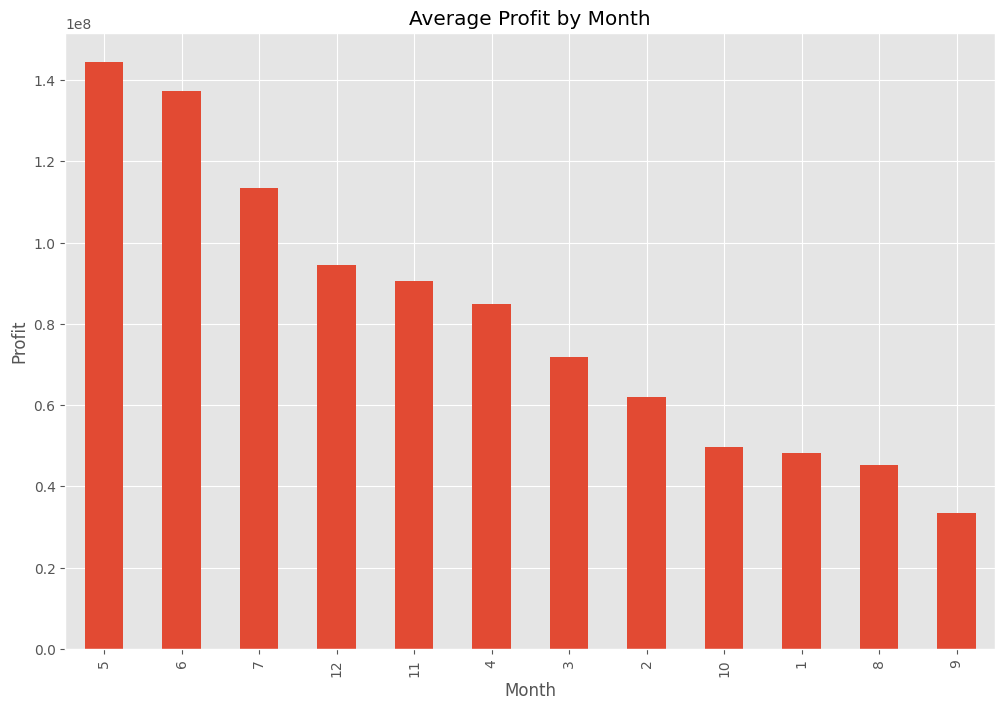

In [52]:
monthly_profit.plot(kind='bar')
plt.title("Average Profit by Month")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()

# Question 4: Which actors and directors tend to add the most value?

In [58]:
merged_df = imdb_budgets_df.copy()

# Merge directors (value column = Director)
merged_df = pd.merge(
    merged_df,
    directors_df[['Movie', 'value']],
    on='Movie',
    how='left'
)

# Merge actors (value column = Actor)
merged_df = pd.merge(
    merged_df,
    actors_df[['Movie', 'value']],
    on='Movie',
    how='left'
)

Top Directors

In [59]:
top_directors = merged_df.groupby('value_x')['Profit'].mean().sort_values(ascending=False).head(10)

top_directors

,Profit
value_x,
Jennifer Lee,1208147942.50
Kyle Balda,1022635171.00
Eric Guillon,959639202.00
Joe Russo,943809141.67
Anthony Russo,943809141.67
Roger Allers,942929736.40
Jared Bush,873784195.00
Josh Cooley,873394813.00
Pierre Coffin,854737937.50


Top Actors

In [60]:
top_actors = merged_df.groupby('value_y')['Profit'].mean().sort_values(ascending=False).head(10)

top_actors

,Profit
value_y,
Ty Simpkins,1455400637.00
Jonathan Groff,1208147942.50
Idina Menzel,1208147942.50
Danai Gurira,1146103376.00
Rafe Spall,1138470988.00
Pierre Coffin,1085631140.00
Huck Milner,1042805359.00
Sarah Vowell,1042805359.00
Zazie Beetz,1017722593.00


# Question 5: How much money should you spend on a movie to win an Oscar?


In [67]:
awards_merged = pd.merge(
    imdb_budgets_df,
    awards_df,
    left_on='Movie',
    right_on='film_name',
    how='left'
)

In [68]:
oscar_movies = awards_merged[awards_merged['awards_won'] > 0]

In [69]:
oscar_movies['Production Budget'].mean()

np.float64(47796248.15445026)

# Question 6: What impact, if any, does runtime and movie rating have on Net Profit, Profit Margin and IMDb rating?

In [72]:
imdb_budgets_df[['Runtime','Profit','ROI']].corr()

,Runtime,Profit,ROI
Runtime,1.00,0.21,-0.05
Profit,0.21,1.00,0.12
ROI,-0.05,0.12,1.00


# Question 7: Sticking to our analysis of Net Profit and Profit Margin, what should Microsoft determine to be the baseline for sustainable success?

In [73]:
# Profit statistics
imdb_budgets_df['Profit'].describe()

# ROI statistics
imdb_budgets_df['ROI'].describe()

,ROI
count,3812.00
mean,3.73
std,15.91
min,-1.00
25%,-0.03
50%,1.17
75%,3.21
max,415.56


# Question 8: Based on the success of current competitors, which should we look to for best practices?  i want to work on this questions

In [76]:
# Merge using correct columns
studio_merged = pd.merge(
    imdb_budgets_df,
    studio_df,
    left_on='Movie',
    right_on='title',
    how='left'
)

# Profit by studio
studio_profit = studio_merged.groupby('studio')['Profit'].mean().sort_values(ascending=False)

studio_profit.head(10)

,Profit
studio,
UTV,656686027.00
Pixar/Dreamworks,374403113.70
Buena Vista,333428238.31
Universal,178870387.08
Fox,173825103.23
Sony,173218018.21
MBox,149373970.00
WB,148395534.28
Paramount,142039655.40


# visualization
1. Budget vs Revenue (Scatter Plot)

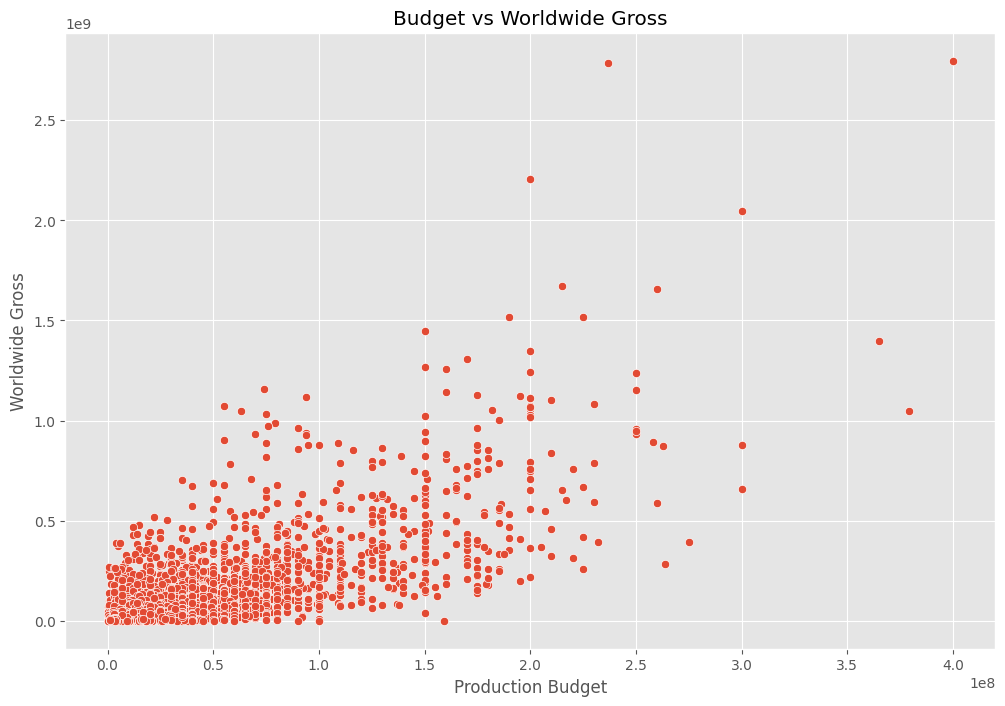

In [77]:
import seaborn as sns

sns.scatterplot(
    data=imdb_budgets_df,
    x='Production Budget',
    y='Worldwide Gross'
)

plt.title("Budget vs Worldwide Gross")
plt.xlabel("Production Budget")
plt.ylabel("Worldwide Gross")

plt.show()

2. Top Genres by Profit (Bar Chart)

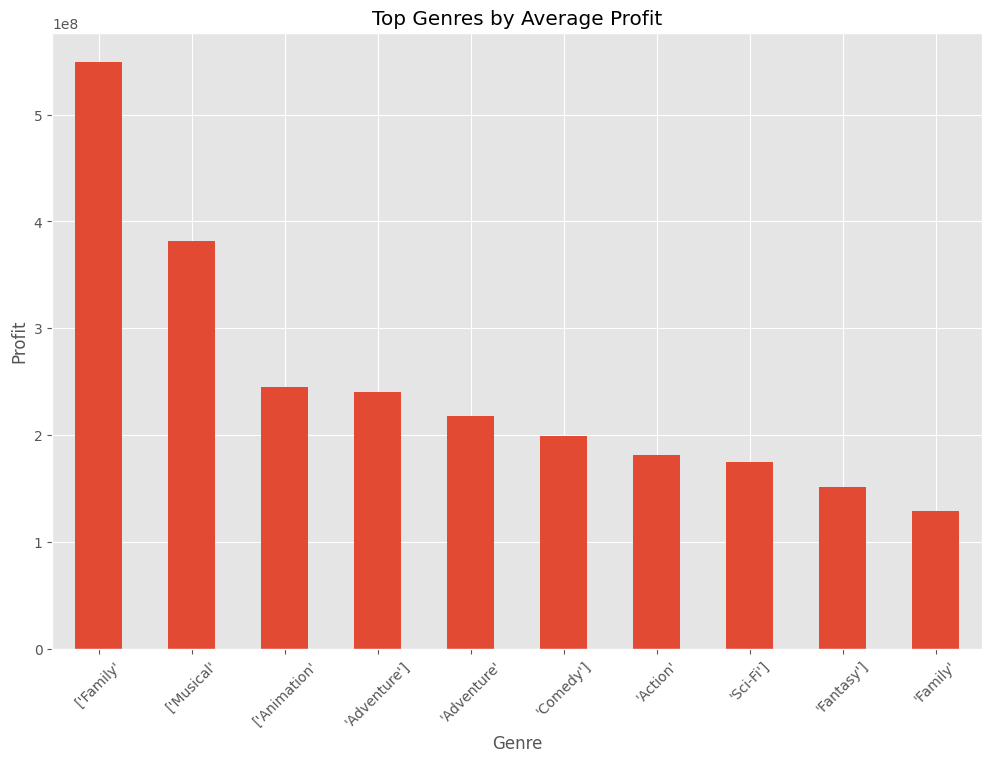

In [78]:
genre_profit.head(10).plot(kind='bar')

plt.title("Top Genres by Average Profit")
plt.xlabel("Genre")
plt.ylabel("Profit")

plt.xticks(rotation=45)
plt.show()

3. Profit Distribution (Histogram)

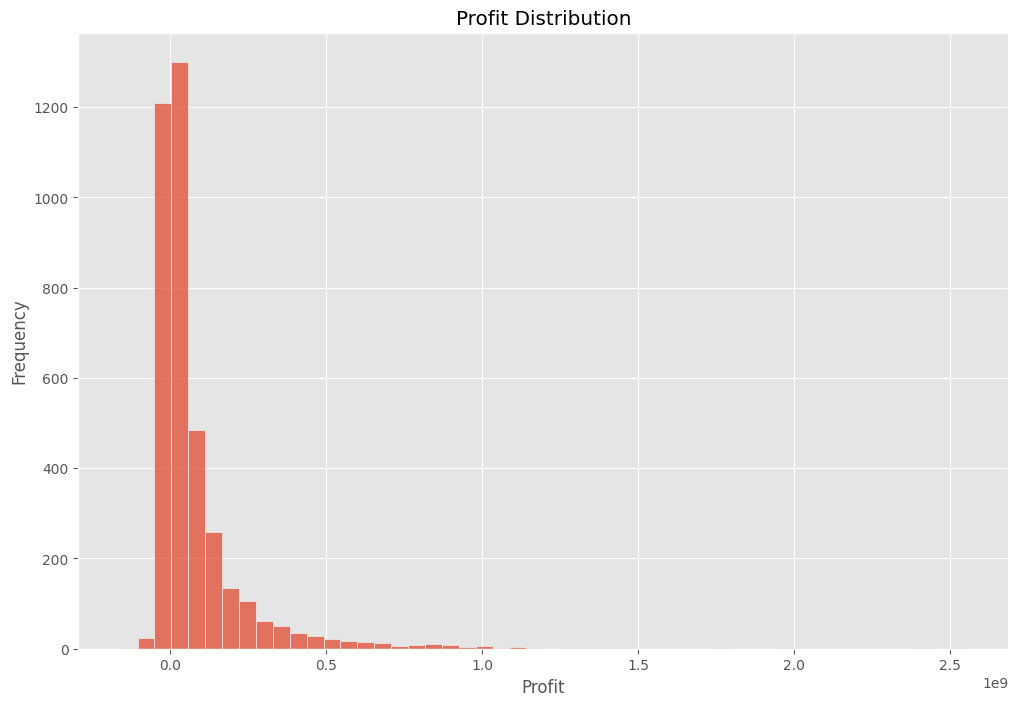

In [79]:
sns.histplot(imdb_budgets_df['Profit'], bins=50)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

4. ROI Distribution

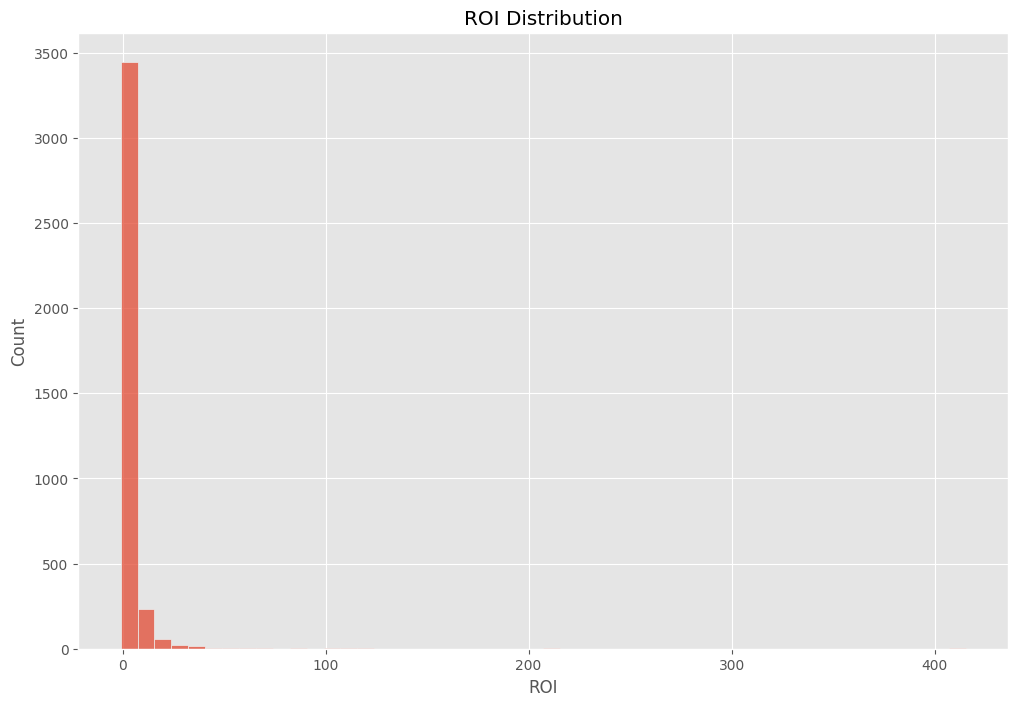

In [80]:
sns.histplot(imdb_budgets_df['ROI'], bins=50)

plt.title("ROI Distribution")
plt.xlabel("ROI")

plt.show()

5.Correlation Heatmap

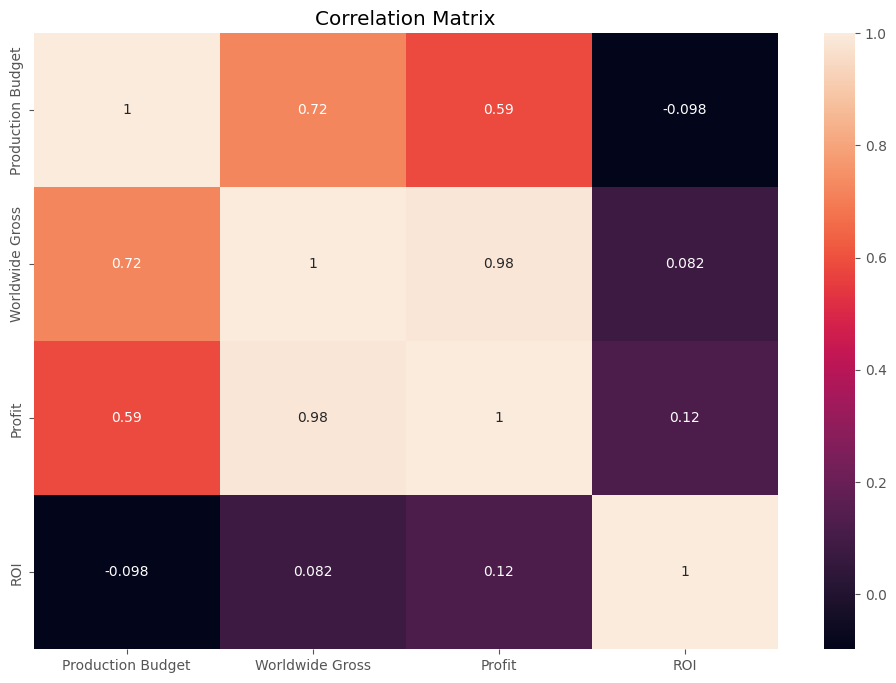

In [82]:
sns.heatmap(
    imdb_budgets_df[['Production Budget','Worldwide Gross','Profit','ROI']].corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()